# 18. What Is an Agent

**Tier:** Agent Engineering
**Estimated time:** 40 minutes
**Prerequisites:** 12, 17
**Priority:** 🔴 Crucial — the conceptual foundation for the entire second half of the curriculum. *If skipped, revisit when:* n/a.
**Source material:** @sairahul1 — Harness Engineering (https://x.com/sairahul1/status/2063544956158185927) ; Stanford LLM curriculum, Lecture 7 (Agentic LLMs)

## What You'll Learn
- The precise difference between a *workflow* and an *agent*
- The four ingredients of every agent: a model, tools, a loop, and memory
- A single tool-call round-trip with Claude — the atom that notebooks 19-23 scale up

## Why This Matters
Tier 3 made the model *know* and *reason*. Tier 4 makes it *act*: call tools, observe what happened, and decide what to do next. Almost every "AI does things for you" product is an agent loop underneath — and the whole loop is built from the one round-trip you'll run in this notebook.


## Agent vs. workflow: who decides what happens next?

A **workflow** is a fixed sequence *you* wrote: retrieve, then summarize, then email. The control flow is in your code; the model just fills in blanks at each step. Notebook 14's RAG pipeline is a workflow.

An **agent** hands the control flow to the model. You give it a goal and a set of tools, and *the model decides* which tool to call, with what arguments, and when it's done. You don't know in advance whether it will search once or five times, or in what order — that's the model's call, made fresh each turn based on what it has seen so far.

Every agent is built from four ingredients:

1. **A model** — the decision-maker (notebook 06), shaped by RLHF (notebook 09) to follow instructions and use tools.
2. **Tools** — functions the model can call to affect the world or gather information (search, read a file, run code). You describe each tool's name, purpose, and inputs; the model picks.
3. **A loop** — call the model → if it asked for a tool, run it and feed the result back → repeat until the model says it's done. This is the heart of notebook 19.
4. **Memory** — the conversation history (notebook 13's context window) carries what's happened so far; longer-term memory is notebook 22's topic.

The single most important mechanic is the **tool-call round-trip**: the model emits a request to call a tool, your code executes it, and you hand the result back. Master that one exchange and the rest of Tier 4 is just looping and orchestrating it. We'll build it three ways across this tier: **raw Claude SDK** (notebook 19), **LangGraph** for orchestration (notebook 20), and **LangSmith** for observability (notebook 21).


In [1]:
import os, json
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"   # production default: claude-opus-4-8

if HAS_ANTHROPIC:
    import anthropic
    client = anthropic.Anthropic()
    print(f"Anthropic ready — agent cells will call {TEACH_MODEL}.")
else:
    client = None
    print("No ANTHROPIC_API_KEY — agent cells will print a skip message. Concept cells still run.")


Anthropic ready — agent cells will call claude-haiku-4-5-20251001.


## The atom: one tool-call round-trip

We give the model exactly one tool — a calculator — and a question it can't reliably answer by itself. Watch the three moves: (1) the model *requests* the tool, (2) we *execute* it, (3) we hand the result back and the model writes the final answer.


In [2]:
# Step 0: describe the tool. The model never sees our Python — only this schema.
CALCULATOR_TOOL = {
    "name": "calculator",
    "description": "Evaluate a basic arithmetic expression and return the numeric result.",
    "input_schema": {
        "type": "object",
        "properties": {
            "expression": {"type": "string", "description": "e.g. '128 * 47 + 9'"},
        },
        "required": ["expression"],
    },
}

# The actual Python that runs when the model asks for the tool.
def run_calculator(expression):
    allowed = set("0123456789+-*/(). ")
    if not set(expression) <= allowed:
        return "error: unsupported characters"
    try:
        return str(eval(expression, {"__builtins__": {}}))   # sandboxed eval for the demo
    except Exception as e:
        return f"error: {e}"

print("Tool defined:", CALCULATOR_TOOL["name"])


Tool defined: calculator


In [3]:
def one_round_trip(question):
    if not HAS_ANTHROPIC:
        print("  [skipped: no ANTHROPIC_API_KEY]")
        return
    messages = [{"role": "user", "content": question}]

    # MOVE 1: ask the model. It can either answer or request the tool.
    resp = client.messages.create(model=TEACH_MODEL, max_tokens=300,
                                   tools=[CALCULATOR_TOOL], messages=messages)
    print(f"[move 1] stop_reason = {resp.stop_reason}")

    if resp.stop_reason == "tool_use":
        tool_use = next(b for b in resp.content if b.type == "tool_use")
        print(f"[move 1] model requested: {tool_use.name}({tool_use.input})")

        # MOVE 2: run the tool ourselves.
        result = run_calculator(**tool_use.input)
        print(f"[move 2] we executed it -> {result}")

        # MOVE 3: hand the result back; the model writes the final answer.
        messages.append({"role": "assistant", "content": resp.content})
        messages.append({"role": "user", "content": [
            {"type": "tool_result", "tool_use_id": tool_use.id, "content": result}
        ]})
        final = client.messages.create(model=TEACH_MODEL, max_tokens=300,
                                       tools=[CALCULATOR_TOOL], messages=messages)
        print(f"[move 3] final answer: {final.content[0].text}")
    else:
        print(f"[move 1] model answered directly: {resp.content[0].text}")

one_round_trip("What is 128 * 47 + 9? Use the calculator to be sure.")


[move 1] stop_reason = tool_use
[move 1] model requested: calculator({'expression': '128 * 47 + 9'})
[move 2] we executed it -> 6025
[move 3] final answer: The answer is **6,025**.

To break it down:
- 128 × 47 = 6,016
- 6,016 + 9 = 6,025


## The same idea, one line higher

`ragkit.llm.generate_tools` wraps move 1 (the "does the model want a tool?" decision) for both Claude and Ollama. It's handy for a single routing decision — but notice it returns only `{name, input}`, *not* the tool-use ID. That's fine for one decision; a multi-turn loop (notebook 19) needs the raw SDK so it can thread each `tool_use_id` back as a `tool_result`.


In [4]:
import sys
sys.path.insert(0, "..")
from ragkit.llm import generate_tools

if HAS_ANTHROPIC:
    decision = generate_tools(
        "What is 256 divided by 4?",
        tools=[CALCULATOR_TOOL],
        system="Use the calculator tool for arithmetic.",
    )
    print("tool_calls:", decision["tool_calls"])
    print("stop_reason:", decision["stop_reason"])
    print("(No tool_use_id here — that's why the loop in notebook 19 uses the raw SDK.)")
else:
    print("  [skipped: no ANTHROPIC_API_KEY]")


tool_calls: [{'name': 'calculator', 'input': {'expression': '256 / 4'}}]
stop_reason: tool_use
(No tool_use_id here — that's why the loop in notebook 19 uses the raw SDK.)


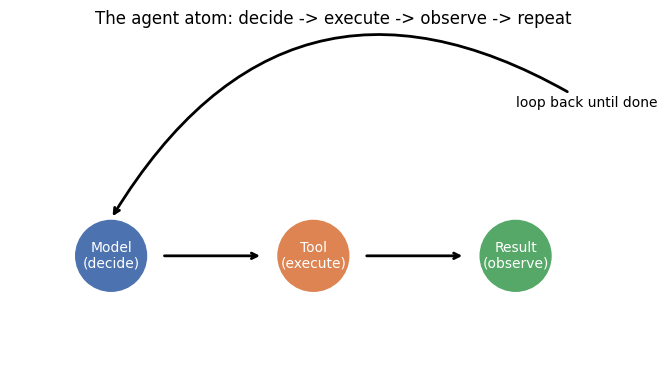

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

# A tiny diagram of the round-trip as a cycle.
fig, ax = plt.subplots(figsize=(7, 4))
steps = ["Model\n(decide)", "Tool\n(execute)", "Result\n(observe)"]
xs = [0, 1, 2]
ax.scatter(xs, [0]*3, s=2600, color=["#4C72B0", "#DD8452", "#55A868"], zorder=3)
for x, s in zip(xs, steps):
    ax.text(x, 0, s, ha="center", va="center", color="white", fontsize=10, zorder=4)
ax.annotate("", xy=(0.75, 0), xytext=(0.25, 0), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(1.75, 0), xytext=(1.25, 0), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("loop back until done", xy=(0, 0.15), xytext=(2, 0.6),
            arrowprops=dict(arrowstyle="->", lw=2, connectionstyle="arc3,rad=0.5"))
ax.set_xlim(-0.5, 2.7); ax.set_ylim(-0.5, 0.9); ax.axis("off")
ax.set_title("The agent atom: decide -> execute -> observe -> repeat")
plt.tight_layout(); plt.show()


*Every agent in this tier is this three-node cycle run repeatedly; notebook 19 turns the single round-trip above into the full loop.*


## Exercises


In [7]:
# Exercise 1 (Warm-up): A question that needs no tool
# Task: Call one_round_trip with a question the model can answer without the calculator
#       (e.g. "What is the capital of France?"). Confirm stop_reason is NOT 'tool_use'.
# Hint: The model only requests a tool when it judges it needs one — that judgement is the
#       whole point of an agent vs. a workflow.

# YOUR CODE HERE
one_round_trip("What is the capital of France?")

one_round_trip("What is (846 - 97) / 2 ? Use the calculator to be sure.")

[move 1] stop_reason = end_turn
[move 1] model answered directly: The capital of France is **Paris**.

Paris is located in the north-central part of France and is the country's largest city. It's known as the "City of Light" and is famous for iconic landmarks such as the Eiffel Tower, Notre-Dame Cathedral, the Louvre Museum, and many others. Paris is also the political, economic, and cultural center of France.
[move 1] stop_reason = tool_use
[move 1] model requested: calculator({'expression': '(846 - 97) / 2'})
[move 2] we executed it -> 374.5
[move 3] final answer: The answer is **374.5**.

To break it down:
- 846 - 97 = 749
- 749 / 2 = 374.5


In [14]:
# Exercise 2 (Apply): Add a second tool
# Task: Define a second tool, get_length(text), that returns len(text), and add it to the tools
#       list. Ask a question that needs it ("How many characters in 'Helios Robotics'?"). Does
#       the model pick the right tool?
# Hint: Give the tool a clear name and description — that text is ALL the model has to decide with.

# YOUR CODE HERE

LENGTH_TOOL = {
    "name": "get_length",
    "description": "Return the length of a given string, equivalent of len(text).",
    "input_schema": {
        "type": "object",
        "properties": {
            "text": {"type": "string", "description": "The string to evaluate."},
        },
        "required": ["text"],
    },
}

resp = client.messages.create(model=TEACH_MODEL, max_tokens=300,
                                   tools=[LENGTH_TOOL], messages=[{"role": "user", "content": "How many characters in 'Rupaul's Drag Race All Stars season 11'?"}])
resp.content[0].name

'get_length'

In [19]:
# Exercise 3 (Extend): Toward the loop
# Task: Modify one_round_trip so that AFTER move 3, if the model's final response is ALSO a
#       tool_use, it runs that tool too. (This is the first step toward the general loop in
#       notebook 19.)
# Hint: Wrap moves 1-3 in a `while resp.stop_reason == "tool_use"` loop instead of a single `if`.

# YOUR CODE HERE

def one_round_trip_ex3(question):
    if not HAS_ANTHROPIC:
        print("  [skipped: no ANTHROPIC_API_KEY]")
        return
    messages = [{"role": "user", "content": question}]
    started = False
    # MOVE 1: ask the model. It can either answer or request the tool.
    resp = client.messages.create(model=TEACH_MODEL, max_tokens=300,
                                   tools=[CALCULATOR_TOOL, LENGTH_TOOL], messages=messages)
    print(f"[move 1] stop_reason = {resp.stop_reason}")
    while not started or resp.stop_reason == "tool_use":
        tool_use = next(b for b in resp.content if b.type == "tool_use")
        print(f"[move 1] model requested: {tool_use.name}({tool_use.input})")
        started = True
        if tool_use.name == "calculator":
            result = run_calculator(**tool_use.input)
        elif tool_use.name == "get_length":
            result = len(tool_use.input["text"])
        result = (tool_use.id, result)
        print(f"[move 2] we executed it -> {result[1]}")
        messages.append({"role": "assistant", "content": resp.content})
        messages.append({"role": "user", "content": [
            {"type": "tool_result", "tool_use_id": result[0], "content": str(result[1])}
        ]})
        resp = client.messages.create(model=TEACH_MODEL, max_tokens=300,
                                        tools=[CALCULATOR_TOOL, LENGTH_TOOL], messages=messages)
        
one_round_trip_ex3("What is 128 * 47 + 9? Use the calculator to be sure, and return the length of the answer as well.")


[move 1] stop_reason = tool_use
[move 1] model requested: calculator({'expression': '128 * 47 + 9'})
[move 2] we executed it -> 6025
[move 1] model requested: get_length({'text': '6025'})
[move 2] we executed it -> 4


<details>
<summary>Show solutions</summary>

```python
# Exercise 1
one_round_trip("What is the capital of France?")   # stop_reason == "end_turn", direct answer

# Exercise 2
LENGTH_TOOL = {
    "name": "get_length",
    "description": "Return the number of characters in a string.",
    "input_schema": {"type": "object",
                     "properties": {"text": {"type": "string"}}, "required": ["text"]},
}
def run_get_length(text): return str(len(text))
TOOLS = {"calculator": run_calculator, "get_length": run_get_length}
schemas = [CALCULATOR_TOOL, LENGTH_TOOL]
if HAS_ANTHROPIC:
    msgs = [{"role": "user", "content": "How many characters are in 'Helios Robotics'?"}]
    r = client.messages.create(model=TEACH_MODEL, max_tokens=200, tools=schemas, messages=msgs)
    tu = next(b for b in r.content if b.type == "tool_use")
    print("picked:", tu.name, tu.input)   # expect get_length

# Exercise 3
def loop_round_trips(question, schemas, tools, max_steps=5):
    messages = [{"role": "user", "content": question}]
    for _ in range(max_steps):
        resp = client.messages.create(model=TEACH_MODEL, max_tokens=300, tools=schemas, messages=messages)
        if resp.stop_reason != "tool_use":
            return resp.content[0].text
        messages.append({"role": "assistant", "content": resp.content})
        results = []
        for b in resp.content:
            if b.type == "tool_use":
                out = tools[b.name](**b.input)
                results.append({"type": "tool_result", "tool_use_id": b.id, "content": out})
        messages.append({"role": "user", "content": results})
    return "stopped: max_steps reached"
# This is essentially notebook 19's loop in miniature.
```
</details>


## Key Takeaways
- A workflow's control flow lives in your code; an agent's control flow is decided by the model, turn by turn.
- Every agent = a model + tools + a loop + memory.
- A tool is just a schema (name, description, inputs) the model can request and a function you run on its behalf — the model never touches your code.
- The tool-call round-trip is the atom: model requests → you execute → you return the result → the model continues.
- `generate_tools` is fine for one decision, but a real loop needs the raw SDK to thread each `tool_use_id` back as a `tool_result`.

## What's Next
Notebook **19 — Agent Loop From Scratch** turns this single round-trip into a full agent: a real loop over multiple tools, with every step of the trace printed, in ~100 lines of raw Anthropic SDK and no framework.
